In [1]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [2]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_imgs(imgs, x_crop, y_crop)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, dict_set_val_sat, intensities_imgs, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if dict_set_val_sat[intensities_imgs[i]] >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp[findfirst(==(intensities_imgs[i]), I_set_value)]/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

compute_OD_high_low_intensity (generic function with 1 method)

In [3]:
pathdir = "//DyLabNAS/Data/TwoDGas/2025/07/04"
dir_names_datasets = readdir(pathdir)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[10:end]
I_set_value = [0.1882, 0.22, 0.35, 0.6, 0.8, 1.0]
sat_exp = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
dict_set_val_sat = Dict(I_set_value[i] => sat_exp[i] for i in eachindex(I_set_value))

τ_exp = [8, 7, 6, 5, 3, 2].*1e-6 # In s
x_crop = [1130:1730;]
y_crop = [1670:2370;]
wrong_shots = []
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2);

# Import and crop the images

In [ ]:
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, intensities_imgs = [], [], [], []

for dir_name_datasets in ProgressBar(dir_names_datasets)
    files_path = readdir(pathdir*"/"*dir_name_datasets)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = load_imgs(files_path, pathdir*"/"*dir_name_datasets*"/")
    push!(imgs_atoms_crop, crop_imgs(imgs_atoms, x_crop, y_crop)), push!(imgs_bkg_crop, crop_imgs(imgs_bkg, x_crop, y_crop)), push!(imgs_dark_crop, crop_imgs(imgs_dark, x_crop, y_crop)), push!(intensities_imgs, intensities)
end

In [ ]:
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, intensities_imgs = vcat(imgs_atoms_crop...), vcat(imgs_bkg_crop...), vcat(imgs_dark_crop...), vcat(intensities_imgs...);

In [8]:
@save "Imgs_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop imgs_bkg_crop imgs_dark_crop intensities_imgs

In [4]:
@load "Imgs_"*join(split(pathdir, "/")[6:end], "_")*".jld2" imgs_atoms_crop imgs_bkg_crop imgs_dark_crop intensities_imgs;

# Compute the ODs

In [5]:
ODs_dataset = compute_OD_high_low_intensity(imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, dict_set_val_sat, intensities_imgs, τ_exp);

# Plot I(s) integrated over the entire picturee

In [6]:
Iatoms, Ibkg, Idark = zeros(length(ODs_dataset)), zeros(length(ODs_dataset)), zeros(length(ODs_dataset))

for i in ProgressBar(1:length((imgs_atoms_crop)))
    if i ∉ wrong_shots
        Convertion_factor = (0.85 * 0.107 * τ_exp[findfirst(==(intensities_imgs[i]), I_set_value)])
        Iatoms[i] = sum(imgs_atoms_crop[i])/Convertion_factor
        Ibkg[i] = sum(imgs_bkg_crop[i])/Convertion_factor
        Idark[i] = sum(imgs_dark_crop[i])/Convertion_factor
    end
end

0.0%┣                                              ┫ 0/300 [00:02<-8:-5, -2s/it]
0.3%┣▏                                         ┫ 1/300 [00:02<Inf:Inf, InfGs/it]
12.0%┣█████▎                                      ┫ 36/300 [00:02<00:16, 17it/s]
26.3%┣███████████▋                                ┫ 79/300 [00:02<00:06, 37it/s]
48.7%┣█████████████████████                      ┫ 146/300 [00:02<00:02, 67it/s]
70.7%┣██████████████████████████████▍            ┫ 212/300 [00:02<00:01, 95it/s]
91.3%┣██████████████████████████████████████▍   ┫ 274/300 [00:02<00:00, 120it/s]
100.0%┣█████████████████████████████████████████┫ 300/300 [00:02<00:00, 130it/s]
100.0%┣█████████████████████████████████████████┫ 300/300 [00:02<00:00, 130it/s]


In [7]:
Iatoms_per_sat, Ibkg_per_sat, Idark_per_sat = zeros((length(sat_exp), Integer(length(Iatoms)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms)/length(sat_exp))))

for i in 1:length(Iatoms)
    if i ∉ wrong_shots
        idx = findfirst(==(intensities_imgs[i]), I_set_value)
        Iatoms_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms)/length(sat_exp))+1))] = Iatoms[i]
        Ibkg_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms)/length(sat_exp))+1))] = Ibkg[i]
        Idark_per_sat[idx, floor(Int64, ((i-1)%(length(Iatoms)/length(sat_exp))+1))] = Idark[i]
    end
end

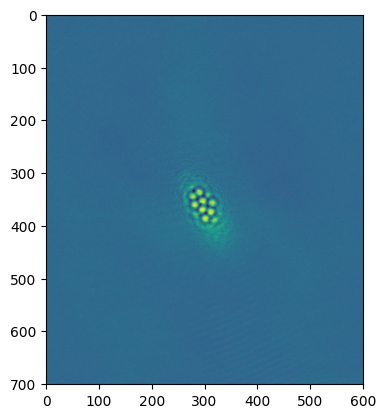

PyObject <matplotlib.image.AxesImage object at 0x00000160688FE3C0>

In [10]:
imshow(ODs_dataset[end])


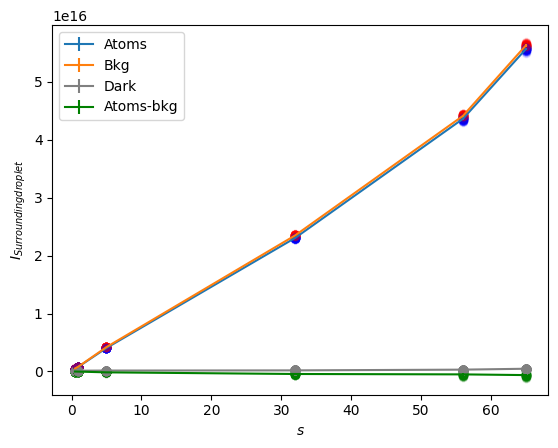

In [8]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_per_sat, dims = 2)), yerr=vec(std(Iatoms_per_sat, dims = 2)), label="Atoms")
errorbar(sat_exp, vec(mean(Ibkg_per_sat, dims = 2)), yerr=vec(std(Ibkg_per_sat, dims = 2)), label="Bkg")
errorbar(sat_exp, vec(mean(Idark_per_sat, dims = 2)), yerr=vec(std(Idark_per_sat, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp, vec(mean(Iatoms_per_sat, dims = 2))-vec(mean(Ibkg_per_sat, dims = 2)), yerr=vec(std(Iatoms_per_sat-Ibkg_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms[i], color="b", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg[i], color="r", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms[i]-Ibkg[i], color="g", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Idark[i], color="grey")
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

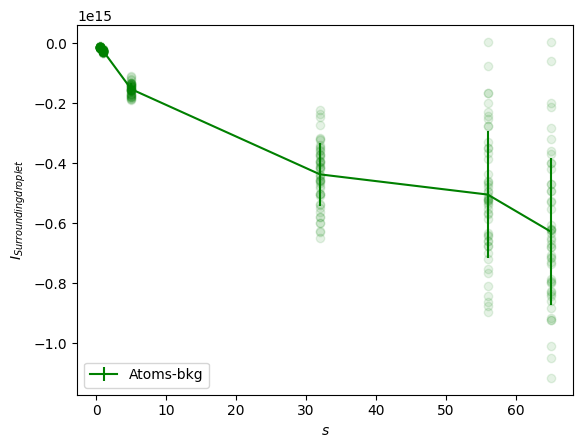

In [9]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_per_sat, dims = 2))-vec(mean(Ibkg_per_sat, dims = 2)), yerr=vec(std(Iatoms_per_sat-Ibkg_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms[i]-Ibkg[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

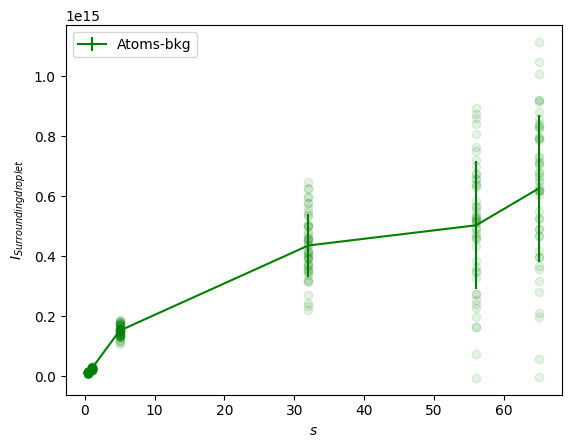

In [11]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Ibkg_per_sat, dims = 2))-vec(mean(Iatoms_per_sat, dims = 2)), yerr=vec(std(Iatoms_per_sat-Ibkg_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg[i]-Iatoms[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

In [18]:
@save "Sol_full_imgs_integrated_"*join(split(pathdir, "/")[6:end], "_")*".jld2" Iatoms_per_sat Ibkg_per_sat Idark_per_sat